# 02 — Pipeline walkthrough: from Wigner symbols to an L-edge spectrum

This notebook walks through the **pure PyTorch** multitorch pipeline,
exposing the tensors at each layer using the `nid8ct` fixture so every
intermediate is reproducible.

The flow:

```
Wigner primitives  →  angular reduced matrix elements
       ↓
COWAN store (.rme_rcg)  +  operator blocks (.rme_rac)  +  recipe (.ban)
       ↓
assemble_and_diagonalize()   →   BanResult (Eg, Ef, T for each triad)
       ↓
get_sticks_from_banresult()  →   Boltzmann-weighted E, M  (autograd-compatible)
       ↓
pseudo_voigt()   →   final broadened spectrum
```

Every step is pure PyTorch, float64, and autograd-compatible. At the end
we optionally compare against Fortran `.ban_out` output to show numerical
agreement.

In [1]:
# Make the notebook runnable from anywhere: chdir to the repo root so
# that relative paths like 'tests/reference_data/...' resolve correctly
# whether you launched jupyter from the repo root or from notebooks/.
import os
from pathlib import Path
_here = Path.cwd()
for _anc in [_here, *_here.parents]:
    if (_anc / "multitorch").is_dir() and (_anc / "tests" / "reference_data").is_dir():
        os.chdir(_anc)
        break
print("working dir:", Path.cwd())

working dir: /Users/afollmer/Follmer_UCD/Follmer_Lab/Code/multiplets/multitorch


## Layer 1 — Wigner primitives

All angular-momentum coupling in the pipeline ultimately bottoms out in
Wigner 3j and 6j symbols. `multitorch.angular.wigner` provides
differentiable, float64 implementations that match the standard
recursions to ~1e-16.

In [2]:
import torch
from multitorch.angular.wigner import wigner3j, wigner6j

# A dipole 3j symbol: < p || C^1 || d >  needs (1, 1, 2; 0, 0, 0)
w3j = wigner3j(1, 1, 2, 0, 0, 0)
print(f"( 1 1 2 ; 0 0 0 ) = {float(w3j):+.12f}")

# Triangle condition check
w3j_bad = wigner3j(1, 1, 4, 0, 0, 0)  # violates triangle inequality
print(f"( 1 1 4 ; 0 0 0 ) = {float(w3j_bad):+.12f}  (should be 0)")

# A sample 6j (appears in angular RME for a 2-shell coupled system)
w6j = wigner6j(2, 1, 1, 1, 2, 2)
print(f"{{ 2 1 1 ; 1 2 2 }} = {float(w6j):+.12f}")

( 1 1 2 ; 0 0 0 ) = +0.365148371670
( 1 1 4 ; 0 0 0 ) = +0.000000000000  (should be 0)
{ 2 1 1 ; 1 2 2 } = +0.152752523165


## Layer 2 — Read the COWAN store and operator blocks

The `.rme_rcg` file is a series of COWAN-format blocks, each a sparse
reduced-matrix-element matrix in an angular-momentum basis. The
`.rme_rac` file is the symmetry-adapted form of the same information.

In [3]:
from pathlib import Path
from multitorch.io.read_rme import read_cowan_store, read_rme_rac_full

REFROOT = Path("tests/reference_data/nid8ct")

cowan_sections = read_cowan_store(str(REFROOT / "nid8ct.rme_rcg"))
print(f"COWAN store: {len(cowan_sections)} sections")
for i, section in enumerate(cowan_sections):
    print(f"  section {i}: {len(section)} matrices")
    for j, mat in enumerate(section[:3]):  # show up to 3 per section
        print(f"    matrix {j+1}: {tuple(mat.shape)}  "
              f"(nonzeros: {int((mat != 0).sum())})")

COWAN store: 4 sections
  section 0: 22 matrices
    matrix 1: (2, 3)  (nonzeros: 3)
    matrix 2: (1, 1)  (nonzeros: 1)
    matrix 3: (1, 3)  (nonzeros: 2)
  section 1: 24 matrices
    matrix 1: (2, 3)  (nonzeros: 3)
    matrix 2: (4, 1)  (nonzeros: 3)
    matrix 3: (4, 3)  (nonzeros: 6)
  section 2: 167 matrices
    matrix 1: (2, 2)  (nonzeros: 2)
    matrix 2: (1, 1)  (nonzeros: 1)
    matrix 3: (3, 3)  (nonzeros: 3)
  section 3: 142 matrices
    matrix 1: (1, 1)  (nonzeros: 1)
    matrix 2: (3, 3)  (nonzeros: 3)
    matrix 3: (4, 4)  (nonzeros: 4)


In [4]:
rac = read_rme_rac_full(str(REFROOT / "nid8ct.rme_rac"))
print(f"RAC file: {len(rac.blocks)} blocks, {len(rac.irreps)} irreps")
# Show a handful of GROUND blocks
for b in rac.blocks[:6]:
    print(f"  {b.kind:7s} {b.bra_sym:4s} {b.geometry:12s} "
          f"bra×ket = {b.n_bra}×{b.n_ket}  (adds: {len(b.add_entries)})")

RAC file: 226 blocks, 40 irreps
  TRANSI  0+   PERP         bra×ket = 9×15  (adds: 11)
  TRANSI  ^0+  PERP         bra×ket = 4×15  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×7  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×7  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×8  (adds: 11)
  TRANSI  1+   PERP         bra×ket = 10×8  (adds: 13)


## Layer 3 — Assemble and diagonalize the Hamiltonian

`assemble_and_diagonalize()` combines `.rme_rcg`, `.rme_rac`, and `.ban`
into a block-diagonal charge-transfer Hamiltonian, diagonalizes it for
each symmetry triad, and returns eigenvalues, eigenvectors, and
transition matrices. This is the PyTorch equivalent of `ttban_exact.f`.

In [5]:
from multitorch.hamiltonian.assemble import assemble_and_diagonalize

result = assemble_and_diagonalize(
    str(REFROOT / "nid8ct.rme_rcg"),
    str(REFROOT / "nid8ct.rme_rac"),
    str(REFROOT / "nid8ct.ban"),
)

print(f"BanResult with {len(result.triads)} triads")
print()
print(f"{'gs':>4s} {'act':>4s} {'fs':>4s}   {'n_gs':>5s} {'n_fs':>5s}   "
      f"{'Eg.min':>10s} {'Ef.min':>10s}")
for t in result.triads[:6]:
    print(f"{t.gs_sym:>4s} {t.act_sym:>4s} {t.fs_sym:>4s}   "
          f"{t.n_gs:>5d} {t.n_fs:>5d}   "
          f"{float(t.Eg.min()):>+10.4f} {float(t.Ef.min()):>+10.4f}")

BanResult with 13 triads

  gs  act   fs    n_gs  n_fs       Eg.min     Ef.min
  0+   1-   1-      22    30      -2.1905  +852.3005
 ^0+   1-   1-      17    30      -2.1648  +852.3005
  1+   1-   0-      35    14      -3.4506  +852.1860
  1+   1-  ^0-      35    14      -3.4506  +852.1915
  1+   1-   2-      35    16      -3.4506  +852.3445
  1+   1-  ^2-      35    16      -3.4506  +852.1720


Pick one triad and look at the transition matrix directly:

Biggest triad: gs=1+ act=^0- fs=1-  T shape = (35, 30)


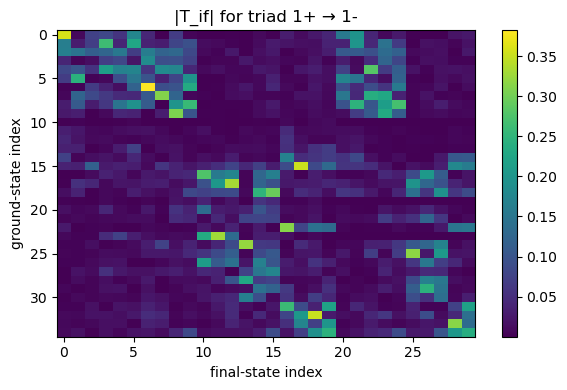

In [6]:
import matplotlib.pyplot as plt

# The largest triad is usually the most informative
biggest = max(result.triads, key=lambda t: t.T.numel())
print(f"Biggest triad: gs={biggest.gs_sym} act={biggest.act_sym} fs={biggest.fs_sym}  "
      f"T shape = {tuple(biggest.T.shape)}")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(biggest.T.abs().detach().numpy(), aspect="auto", cmap="viridis")
ax.set_xlabel("final-state index")
ax.set_ylabel("ground-state index")
ax.set_title(f"|T_if| for triad {biggest.gs_sym} → {biggest.fs_sym}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Layer 4 — Boltzmann sticks from the PyTorch BanResult

`get_sticks_from_banresult()` takes the `BanResult` we just computed
(pure PyTorch) and produces Boltzmann-weighted stick energies and
intensities. This is the autograd-compatible path — gradients flow
through the entire chain from atomic parameters to the stick spectrum.

In [7]:
from multitorch.spectrum.sticks import get_sticks_from_banresult

E_sticks, M_sticks, Eg_min = get_sticks_from_banresult(result, T=80.0, max_gs=1)
print(f"{E_sticks.shape[0]} sticks from PyTorch BanResult; "
      f"E range [{float(E_sticks.min()):.2f}, {float(E_sticks.max()):.2f}] eV")
print(f"All tensors on autograd tape: E.requires_grad={E_sticks.requires_grad}, "
      f"M.requires_grad={M_sticks.requires_grad}")

90 sticks from PyTorch BanResult; E range [855.62, 880.01] eV
All tensors on autograd tape: E.requires_grad=False, M.requires_grad=False


## Layer 5 — Broadening: pseudo-Voigt convolution

`pseudo_voigt()` convolves the stick spectrum into a smooth curve using
a Thompson et al. (1987) pseudo-Voigt profile. Both Gaussian and
Lorentzian FWHM parameters can be `torch.Tensor` values, keeping the
autograd tape alive through the broadening step.

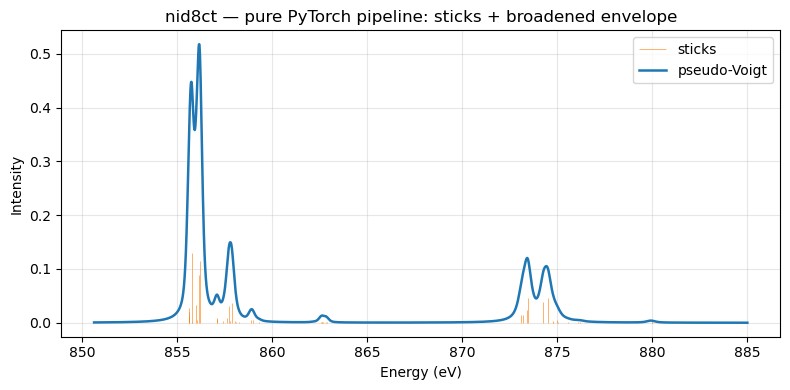

In [8]:
from multitorch.spectrum.broaden import pseudo_voigt

# Build the broadened spectrum on a dense grid
x_grid = torch.linspace(float(E_sticks.min()) - 5.0,
                        float(E_sticks.max()) + 5.0,
                        2000, dtype=torch.float64)
med = 0.5 * (float(E_sticks.min()) + float(E_sticks.max()))
y_grid = pseudo_voigt(
    x_grid, E_sticks, M_sticks,
    fwhm_g=0.2, fwhm_l=0.2, fwhm_l2=0.4,
    med_energy=med, mode="correct",
)

fig, ax = plt.subplots(figsize=(8, 4))
# stick plot via vlines
ax.vlines(E_sticks.detach().numpy(), 0, M_sticks.detach().numpy(),
          color="C1", lw=0.6, alpha=0.7, label="sticks")
ax.plot(x_grid.numpy(), y_grid.detach().numpy(), "C0", lw=1.8, label="pseudo-Voigt")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Intensity")
ax.set_title("nid8ct — pure PyTorch pipeline: sticks + broadened envelope")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Appendix — Comparison with Fortran `.ban_out`

The Fortran `ttban_exact` program computes the same eigenvalues and
transition matrices. Let's read its output and verify the PyTorch
pipeline agrees numerically.

In [9]:
from multitorch.io.read_oba import read_ban_output
from multitorch.spectrum.sticks import get_sticks

ban = read_ban_output(str(REFROOT / "nid8ct.ban_out"))
print(f"Fortran .ban_out: {len(ban.triad_list)} triads")

# Compare eigenvalues: PyTorch assembler vs Fortran
py_first = result.triads[0]
fort_match = None
for t in ban.triad_list:
    if (t.ground_sym == py_first.gs_sym and t.op_sym == py_first.act_sym
            and t.final_sym == py_first.fs_sym):
        fort_match = t
        break

if fort_match is not None:
    dE = abs(float(py_first.Eg.min()) - float(fort_match.Eg.min()))
    print(f"\nFirst triad {py_first.gs_sym} -> {py_first.fs_sym}:")
    print(f"  Eg.min PyTorch = {float(py_first.Eg.min()):+.6f} Ry")
    print(f"  Eg.min Fortran = {float(fort_match.Eg.min()):+.6f} Ry")
    print(f"  |delta E|      = {dE:.2e} Ry")

# Compare broadened spectra
E_fort, M_fort, _ = get_sticks(ban, T=80.0, max_gs=1)
y_fort = pseudo_voigt(
    x_grid, E_fort, M_fort,
    fwhm_g=0.2, fwhm_l=0.2, fwhm_l2=0.4,
    med_energy=med, mode="correct",
)
cosine_sim = float(torch.nn.functional.cosine_similarity(
    y_grid.detach().unsqueeze(0), y_fort.unsqueeze(0)))
print(f"\nSpectral cosine similarity (PyTorch vs Fortran): {cosine_sim:.6f}")

Fortran .ban_out: 15 triads

First triad 0+ -> 1-:
  Eg.min PyTorch = -2.190454 Ry
  Eg.min Fortran = -2.190450 Ry
  |delta E|      = 4.45e-06 Ry

Spectral cosine similarity (PyTorch vs Fortran): 1.000000


## Recap

| Layer | Function | Output |
|---|---|---|
| Wigner 3j/6j | `wigner3j`, `wigner6j` | angular coupling coefficients |
| COWAN store + RAC | `read_cowan_store`, `read_rme_rac_full` | sparse RME matrices |
| Hamiltonian | `assemble_and_diagonalize` | `BanResult` (Eg, Ef, T per triad) |
| Sticks | `get_sticks_from_banresult` | Boltzmann-weighted (E, M) tensors |
| Broadening | `pseudo_voigt` | smooth (x, y) spectrum |

The entire pipeline is **pure PyTorch, float64, autograd-compatible**.
No Fortran is called at any point. The high-level API
`calcXAS(element, valence, sym, edge, cf, slater, soc)` wraps all of
the above into a single call with full gradient support.